# Training Pipeline (Sections 5-End)
# Integrated Multi-Dataset Deepfake Detection

## Overview
This notebook handles **model training, evaluation, and analysis** using
precomputed features from `preprocess_sections2_4.ipynb`.

### Prerequisites
Run `preprocess_sections2_4.ipynb` first to generate:
- `extracted_features_integrated/` - Feature vectors
- `preprocessing_manifest.csv` - Sample manifest

### Configurable Parameters
- **`TRAINING_SAMPLE_PERCENTAGE`** - Fraction of preprocessed data to use
  (e.g., 0.10, 0.25, 0.50, 1.0)
- All training hyperparameters (learning rate, epochs, batch size, etc.)

### Sections
5. Attention Mechanisms
6. Complete Attention Model
7. Dataset Classes (manifest-based, no filesystem scanning)
8. Training Utilities
9. Training
10-11. Cross-Dataset Evaluation
12-13. Analysis & Summary

## Section 1: Setup & Configuration

In [ ]:
# ============================================================================
# IMPORTS
# ============================================================================

import os
import json
import numpy as np
import pandas as pd
import random
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Analysis and visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

# ============================================================================
# SET RANDOM SEED
# ============================================================================

def set_seed(seed=42):
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

# ============================================================================
# DEVICE CONFIGURATION
# ============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"{'='*70}")
print("ENVIRONMENT SETUP")
print(f"{'='*70}")
print(f"Using device: {device}")
print(f"PyTorch Version: {torch.__version__}")
print(f"{'='*70}")

In [ ]:
# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    """Central configuration for the training pipeline."""

    # ==========================================================================
    # TRAINING SAMPLE PERCENTAGE  <-- CHANGE THIS TO ITERATE FASTER
    # ==========================================================================
    # Controls what fraction of the preprocessed data to use for training.
    # Set to 1.0 to use all preprocessed data, or lower values for faster runs.
    # Examples: 0.10 (10%), 0.25 (25%), 0.50 (50%), 1.0 (100%)
    TRAINING_SAMPLE_PERCENTAGE = 1.0

    # ==========================================================================
    # Preprocessing percentages (reference only - set in Notebook A)
    # Set to 1.0 when preprocessing used 100% of each dataset.
    # ==========================================================================
    FFPP_PERCENTAGE = 1.0
    CELEBDF_PERCENTAGE = 1.0
    DFDC_PERCENTAGE = 1.0
    HIDF_PERCENTAGE = 1.0

    # ==========================================================================
    # Paths
    # ==========================================================================
    BASE_DIR = Path('.')

    DATA_ROOT = BASE_DIR / 'extraction'
    FEATURES_DIR = DATA_ROOT / 'extracted_features_integrated'
    CHECKPOINTS_DIR = BASE_DIR / 'checkpoints'
    RESULTS_DIR = BASE_DIR / 'results'
    MANIFEST_PATH = DATA_ROOT / 'preprocessing_manifest.csv'
    INTEGRATED_METADATA_PATH = DATA_ROOT / 'integrated_nocuda.csv'

    # Data settings
    TRAIN_RATIO = 0.8

    # Feature dimensions
    SPATIAL_DIM = 2048   # Xception output
    FREQ_DIM = 128         # Azimuthal power spectrum (128-dim)
    SEMANTIC_DIM = 768   # CLIP ViT-B/32 output

    # Training settings
    BATCH_SIZE = 128
    LEARNING_RATE = 1e-4
    EPOCHS = 20
    HIDDEN_DIM1 = 512
    HIDDEN_DIM2 = 256
    DROPOUT = 0.5
    FUSION_DIM = 512

    # Early stopping
    PATIENCE = 5
    MIN_DELTA = 0.001

config = Config()

# Create necessary directories
for dir_path in [config.CHECKPOINTS_DIR, config.RESULTS_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

print(f"\n{'='*70}")
print("TRAINING CONFIGURATION")
print(f"{'='*70}")
print(f"Training Sample Percentage: {config.TRAINING_SAMPLE_PERCENTAGE * 100:.0f}%")
print(f"Preprocessing Percentages (from Notebook A):")
print(f"  - FaceForensics++: {config.FFPP_PERCENTAGE * 100:.1f}%")
print(f"  - Celeb-DF: {config.CELEBDF_PERCENTAGE * 100:.1f}%")
print(f"  - DFDC: {config.DFDC_PERCENTAGE * 100:.1f}%")
print(f"  - HiDF: {config.HIDF_PERCENTAGE * 100:.1f}%")
print(f"Data root: {config.DATA_ROOT}")
print(f"Features dir: {config.FEATURES_DIR}")
print(f"Manifest path: {config.MANIFEST_PATH}")
print(f"Batch size: {config.BATCH_SIZE}")
print(f"Learning rate: {config.LEARNING_RATE}")
print(f"Epochs: {config.EPOCHS}")
print(f"Feature dimensions: Spatial={config.SPATIAL_DIM}, Freq={config.FREQ_DIM}, Semantic={config.SEMANTIC_DIM}")
print(f"{'='*70}")

## Load Preprocessing Manifest

Load the sample manifest generated by `preprocess_sections2_4.ipynb`.
This avoids slow filesystem re-scanning on every training run.

In [ ]:
# ============================================================================
# LOAD PREPROCESSING MANIFEST
# ============================================================================

if not config.MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Manifest not found: {config.MANIFEST_PATH}\n"
        f"Run preprocess_sections2_4.ipynb first to generate it."
    )

manifest_df = pd.read_csv(config.MANIFEST_PATH)
print(f"Loaded manifest: {len(manifest_df)} samples")

# Apply training sample percentage (stratified by dataset and label)
if config.TRAINING_SAMPLE_PERCENTAGE < 1.0:
    original_count = len(manifest_df)
    manifest_df = manifest_df.groupby(['dataset', 'label'], group_keys=False).apply(
        lambda x: x.sample(frac=config.TRAINING_SAMPLE_PERCENTAGE, random_state=42)
    ).reset_index(drop=True)
    print(f"Sampled {config.TRAINING_SAMPLE_PERCENTAGE*100:.0f}%: {len(manifest_df)} / {original_count} samples")

print(f"\nManifest summary:")
print(f"  By label: {manifest_df['label'].value_counts().to_dict()}")
print(f"  By dataset:")
for ds, count in manifest_df['dataset'].value_counts().items():
    label_counts = manifest_df[manifest_df['dataset'] == ds]['label'].value_counts().to_dict()
    print(f"    {ds}: {count} (real={label_counts.get('real', 0)}, fake={label_counts.get('fake', 0)})")

## Section 5: Attention Mechanisms

In [13]:
# ============================================================================
# ATTENTION MODULES
# ============================================================================

class ChannelAttention(nn.Module):
    """Squeeze-and-Excitation (SE) Channel Attention."""
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction, in_channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        weights = self.fc(x)
        return x * weights, weights


class FrequencyBandAttention(nn.Module):
    """SE-style attention for frequency domain features (128-dim).

    Upgraded from the original 4-dim version. Uses a bottleneck
    (reduction=8) to learn which frequency bands are most informative.
    """
    def __init__(self, num_features=128, reduction=8):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(num_features, num_features // reduction),
            nn.ReLU(),
            nn.Linear(num_features // reduction, num_features),
            nn.Sigmoid()
        )

    def forward(self, x):
        weights = self.attention(x)
        return x * weights, weights


class SelfAttention(nn.Module):
    """Self-attention module for semantic features."""
    def __init__(self, dim, num_heads=8):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        B, D = x.size()
        x = x.unsqueeze(1)
        qkv = self.qkv(x).reshape(B, 1, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)

        out = (attn @ v).transpose(1, 2).reshape(B, 1, D)
        out = self.proj(out).squeeze(1)

        return self.norm(x.squeeze(1) + out)


class DomainAttentionFusion(nn.Module):
    """Learnable attention-based fusion with temperature scaling.

    Temperature > 1 spreads attention across all domains, preventing
    the network from collapsing to a single-domain shortcut (e.g., 99.8% semantic).
    """
    def __init__(self, spatial_dim, freq_dim, semantic_dim, fusion_dim=512):
        super().__init__()

        self.spatial_proj = nn.Linear(spatial_dim, fusion_dim)
        self.freq_proj = nn.Linear(freq_dim, fusion_dim)
        self.semantic_proj = nn.Linear(semantic_dim, fusion_dim)

        self.domain_attention = nn.Sequential(
            nn.Linear(fusion_dim * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 3)
        )

        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Learnable temperature (initialized > 1 to encourage spread)
        self.temperature = nn.Parameter(torch.tensor(2.0))

    def forward(self, spatial_feat, freq_feat, semantic_feat):
        spatial_proj = torch.clamp(self.spatial_proj(spatial_feat), -100, 100)
        freq_proj = torch.clamp(self.freq_proj(freq_feat), -100, 100)
        semantic_proj = torch.clamp(self.semantic_proj(semantic_feat), -100, 100)

        domain_stack = torch.stack([spatial_proj, freq_proj, semantic_proj], dim=1)

        concat_features = torch.cat([spatial_proj, freq_proj, semantic_proj], dim=1)
        attention_logits = self.domain_attention(concat_features)

        # Temperature-scaled softmax (prevents single-domain collapse)
        attention_logits = attention_logits - attention_logits.max(dim=1, keepdim=True)[0]
        temp = self.temperature.clamp(min=0.5)
        domain_weights = torch.softmax(attention_logits / temp, dim=1)

        if torch.isnan(domain_weights).any():
            domain_weights = torch.ones_like(domain_weights) / 3.0

        weighted_features = domain_stack * domain_weights.unsqueeze(-1)
        fused = weighted_features.sum(dim=1)

        return self.fusion(fused), domain_weights

print("Attention modules defined:")
print("  - ChannelAttention (SE) for spatial features")
print("  - FrequencyBandAttention (SE, 128-dim) for frequency features")
print("  - SelfAttention for semantic features")
print("  - DomainAttentionFusion with temperature scaling")

## Section 6: Complete Attention Model

In [14]:
# ============================================================================
# COMPLETE ATTENTION MODEL (3-Domain: Spatial + Frequency + Semantic)
# ============================================================================

class CompleteAttentionModel(nn.Module):
    """
    Complete attention model with:
    1. Individual domain attention (SE, Frequency Band, Self-Attention)
    2. Temperature-scaled attention fusion
    3. Domain dropout during training (prevents semantic dominance)
    """

    def __init__(self, spatial_dim, freq_dim, semantic_dim, hidden_dim1=512, hidden_dim2=256, dropout=0.5):
        super().__init__()

        # Domain-specific attention
        self.spatial_attention = ChannelAttention(spatial_dim, reduction=16)
        self.freq_attention = FrequencyBandAttention(freq_dim)
        self.semantic_attention = SelfAttention(semantic_dim)

        # Fusion with temperature scaling
        self.fusion = DomainAttentionFusion(spatial_dim, freq_dim, semantic_dim, hidden_dim1)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim2, 1)
        )

        # Store weights for visualization
        self.last_domain_weights = None
        self.last_spatial_weights = None
        self.last_freq_weights = None

        # Domain dropout: randomly drop domains during training
        # Forces the model to learn useful representations in ALL domains
        self.domain_dropout_prob = 0.15

    def forward(self, spatial, freq, semantic):
        # Apply domain-specific attention
        spatial_attended, spatial_weights = self.spatial_attention(spatial)
        freq_attended, freq_weights = self.freq_attention(freq)
        semantic_attended = self.semantic_attention(semantic)

        self.last_spatial_weights = spatial_weights.detach()
        self.last_freq_weights = freq_weights.detach()

        # Domain dropout during training
        if self.training:
            drop_mask = torch.rand(3) > self.domain_dropout_prob
            if not drop_mask.any():
                drop_mask[torch.randint(3, (1,))] = True  # keep at least one
            if not drop_mask[0]:
                spatial_attended = torch.zeros_like(spatial_attended)
            if not drop_mask[1]:
                freq_attended = torch.zeros_like(freq_attended)
            if not drop_mask[2]:
                semantic_attended = torch.zeros_like(semantic_attended)

        # Fusion
        fused, domain_weights = self.fusion(spatial_attended, freq_attended, semantic_attended)
        self.last_domain_weights = domain_weights.detach()

        return self.classifier(fused)

print("  CompleteAttentionModel defined:")
print("    - Domain dropout (p=0.15) prevents semantic dominance")
print("    - Temperature-scaled fusion spreads attention across domains")

## Section 7: Dataset Classes for Training

In [ ]:
# ============================================================================
# DATASET CLASSES (Video-level split + Z-score normalization)
# ============================================================================

class IntegratedMultiDomainDataset(Dataset):
    """
    Dataset for multi-domain features from integrated datasets.

    Key fixes over original:
    - VIDEO-LEVEL SPLIT: Prevents data leakage by splitting at video_id level
      (all frames from a video go to the same split)
    - STRATIFIED: Split is stratified by (dataset, label) for balance
    - Z-SCORE NORMALIZATION: Per-domain normalization using training set statistics
    """

    def __init__(self, split='train', dataset_filter=None, norm_stats=None):
        self.samples = []
        self.norm_stats = norm_stats

        # Use preloaded manifest
        df = manifest_df.copy()

        if dataset_filter:
            if isinstance(dataset_filter, str):
                df = df[df['dataset'] == dataset_filter]
            elif isinstance(dataset_filter, list):
                df = df[df['dataset'].isin(dataset_filter)]

        # Build sample list with video_id for grouping
        all_samples = []
        for _, row in df.iterrows():
            label_int = 1 if row['label'] == 'fake' else 0
            all_samples.append({
                'spatial': config.FEATURES_DIR / 'spatial' / row['label'] / row['video_id'] / f"{row['frame_name']}.npy",
                'frequency': config.FEATURES_DIR / 'frequency' / row['label'] / row['video_id'] / f"{row['frame_name']}.npy",
                'semantic': config.FEATURES_DIR / 'semantic' / row['label'] / row['video_id'] / f"{row['frame_name']}.npy",
                'label': label_int,
                'dataset': row['dataset'],
                'video_id': row['video_id'],
            })

        print(f"  [{split.upper()}] Total manifest samples: {len(all_samples)}")

        if len(all_samples) == 0:
            print(f"  Warning: No samples found for filter={dataset_filter}")
            return

        # ── VIDEO-LEVEL SPLIT (prevents data leakage) ──
        # Group by video_id, split video_ids (not frames)
        video_df = df[['video_id', 'dataset', 'label']].drop_duplicates(subset='video_id')
        strata = video_df['dataset'] + '_' + video_df['label']

        from sklearn.model_selection import train_test_split
        train_vids, val_vids = train_test_split(
            video_df['video_id'].values,
            test_size=1.0 - config.TRAIN_RATIO,
            random_state=42,
            stratify=strata.values
        )

        if split == 'train':
            selected_vids = set(train_vids)
        else:
            selected_vids = set(val_vids)

        self.samples = [s for s in all_samples if s['video_id'] in selected_vids]

        # Count stats
        if len(self.samples) > 0:
            self.real_count = sum(1 for s in self.samples if s['label'] == 0)
            self.fake_count = sum(1 for s in self.samples if s['label'] == 1)
            n_vids = len(selected_vids)

            ds_counts = {}
            for s in self.samples:
                ds_counts[s['dataset']] = ds_counts.get(s['dataset'], 0) + 1
            ds_str = ", ".join(f"{k}={v}" for k, v in sorted(ds_counts.items()))

            print(f"  [{split.upper()}] {len(self.samples)} frames from {n_vids} videos (Real: {self.real_count}, Fake: {self.fake_count})")
            print(f"    Per-dataset: {ds_str}")

    def __len__(self):
        return len(self.samples)

    def get_pos_weight(self):
        if hasattr(self, 'real_count') and hasattr(self, 'fake_count') and self.fake_count > 0:
            return torch.tensor([self.real_count / self.fake_count], dtype=torch.float32)
        return torch.tensor([1.0])

    @staticmethod
    def compute_norm_stats(samples, max_samples=10000):
        """Compute per-domain mean/std from a subset of training samples."""
        n = min(len(samples), max_samples)
        indices = np.random.RandomState(42).choice(len(samples), n, replace=False)

        all_spatial, all_freq, all_semantic = [], [], []
        for i in indices:
            s = samples[i]
            all_spatial.append(np.load(s['spatial']).astype(np.float32))
            all_freq.append(np.load(s['frequency']).astype(np.float32))
            all_semantic.append(np.load(s['semantic']).astype(np.float32))

        spatial_arr = np.stack(all_spatial)
        freq_arr = np.stack(all_freq)
        semantic_arr = np.stack(all_semantic)

        stats = {
            'spatial_mean': spatial_arr.mean(axis=0),
            'spatial_std': spatial_arr.std(axis=0) + 1e-8,
            'freq_mean': freq_arr.mean(axis=0),
            'freq_std': freq_arr.std(axis=0) + 1e-8,
            'semantic_mean': semantic_arr.mean(axis=0),
            'semantic_std': semantic_arr.std(axis=0) + 1e-8,
        }
        print(f"  Norm stats computed from {n} samples")
        return stats

    def __getitem__(self, idx):
        sample = self.samples[idx]
        spatial = np.load(sample['spatial']).astype(np.float32)
        frequency = np.load(sample['frequency']).astype(np.float32)
        semantic = np.load(sample['semantic']).astype(np.float32)
        label = np.float32(sample['label'])

        # NaN/Inf protection
        for arr in [spatial, frequency, semantic]:
            mask = np.isnan(arr) | np.isinf(arr)
            if np.any(mask):
                arr[mask] = 0.0

        # Z-score normalization (stats from training set)
        if self.norm_stats is not None:
            spatial = (spatial - self.norm_stats['spatial_mean']) / self.norm_stats['spatial_std']
            frequency = (frequency - self.norm_stats['freq_mean']) / self.norm_stats['freq_std']
            semantic = (semantic - self.norm_stats['semantic_mean']) / self.norm_stats['semantic_std']

        return (
            torch.from_numpy(spatial),
            torch.from_numpy(frequency),
            torch.from_numpy(semantic),
            torch.tensor(label)
        )

print("  IntegratedMultiDomainDataset defined:")
print("    - Video-level train/val split (no data leakage)")
print("    - Stratified by (dataset, label)")
print("    - Z-score normalization with compute_norm_stats()")

## Section 8: Training Utilities

In [16]:
# ============================================================================
# TRAINING UTILITIES
# ============================================================================

class EarlyStopping:
    """Early stopping to prevent overfitting."""
    
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
    
    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0


def train_complete_attention_model(dataset_filter=None, model_name='complete_attention_integrated', epochs=None):
    """
    Train the Complete Attention Model on integrated datasets.
    Uses class-weighted loss to handle data imbalance.
    Uses all extracted features for train/validation split.
    
    Args:
        dataset_filter: Optional - train on specific dataset(s)
        model_name: Name for saving checkpoints
        epochs: Number of epochs (None uses config default)
    
    Returns:
        dict: Training results including model, history, and metrics
    """
    epochs = epochs or config.EPOCHS
    
    # Print current percentage configuration for verification
    print(f"\n{'='*70}")
    print(f"DATA PERCENTAGE CONFIGURATION (from Config)")
    print(f"{'='*70}")
    print(f"  FaceForensics++: {config.FFPP_PERCENTAGE*100:.1f}%")
    print(f"  Celeb-DF:        {config.CELEBDF_PERCENTAGE*100:.1f}%")
    print(f"  DFDC:            {config.DFDC_PERCENTAGE*100:.1f}%")
    print(f"  HiDF:            {config.HIDF_PERCENTAGE*100:.1f}%")
    
    # Create datasets with video-level split and z-score normalization
    print(f"\nCreating training dataset (video-level split)...")
    train_dataset = IntegratedMultiDomainDataset(split='train', dataset_filter=dataset_filter)

    # Compute normalization stats from training set
    print(f"\nComputing normalization statistics...")
    norm_stats = IntegratedMultiDomainDataset.compute_norm_stats(train_dataset.samples)
    train_dataset.norm_stats = norm_stats

    print(f"\nCreating validation dataset...")
    val_dataset = IntegratedMultiDomainDataset(split='val', dataset_filter=dataset_filter, norm_stats=norm_stats)
    
    if len(train_dataset) == 0:
        print(f"  No training data available for {dataset_filter or 'all datasets'}")
        return None
    
    train_loader = DataLoader(
        train_dataset, 
        batch_size=config.BATCH_SIZE, 
        shuffle=True, 
        num_workers=0, 
        pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, 
        batch_size=config.BATCH_SIZE, 
        shuffle=False, 
        num_workers=0, 
        pin_memory=True
    )
    
    # Create model
    model = CompleteAttentionModel(
        config.SPATIAL_DIM, config.FREQ_DIM, config.SEMANTIC_DIM,
        config.HIDDEN_DIM1, config.HIDDEN_DIM2, config.DROPOUT
    ).to(device)
    
    # Class-weighted loss to handle imbalance
    pos_weight = train_dataset.get_pos_weight().to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    early_stopping = EarlyStopping(patience=config.PATIENCE)
    
    history = {
        'train_loss': [], 'val_loss': [], 'val_accuracy': [],
        'val_precision': [], 'val_recall': [], 'val_f1': [],
        'val_auc': [], 'domain_weights': []
    }
    best_val_f1 = 0.0
    best_val_acc = 0.0
    
    filter_str = dataset_filter if dataset_filter else 'All Datasets'
    print(f"\n{'='*70}")
    print(f"Training COMPLETE ATTENTION MODEL")
    print(f"Dataset: {filter_str}")
    print(f"{'='*70}")
    print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")
    print(f"Params: {sum(p.numel() for p in model.parameters()):,}")
    print(f"pos_weight (class balance): {pos_weight.item():.4f}")
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        
        for spatial, freq, semantic, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            spatial = spatial.to(device)
            freq = freq.to(device)
            semantic = semantic.to(device)
            labels = labels.to(device).unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(spatial, freq, semantic)
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item()
        
        # Step scheduler
        scheduler.step()
        
        # Validation
        model.eval()
        val_loss = 0.0
        all_preds, all_labels, all_probs = [], [], []
        all_domain_weights = []
        
        with torch.no_grad():
            for spatial, freq, semantic, labels in val_loader:
                spatial = spatial.to(device)
                freq = freq.to(device)
                semantic = semantic.to(device)
                labels = labels.to(device).unsqueeze(1)
                
                outputs = model(spatial, freq, semantic)
                val_loss += criterion(outputs, labels).item()
                
                probs = torch.sigmoid(outputs).cpu().numpy().flatten()
                preds = probs >= 0.5
                all_probs.extend(probs)
                all_preds.extend(preds)
                all_labels.extend(labels.cpu().numpy().flatten())
                
                if model.last_domain_weights is not None:
                    all_domain_weights.append(model.last_domain_weights.cpu().numpy())
        
        # Metrics
        val_acc = accuracy_score(all_labels, all_preds)
        val_prec = precision_score(all_labels, all_preds, zero_division=0)
        val_rec = recall_score(all_labels, all_preds, zero_division=0)
        val_f1 = f1_score(all_labels, all_preds, zero_division=0)
        try:
            val_auc = roc_auc_score(all_labels, all_probs)
        except:
            val_auc = 0.0
        
        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_accuracy'].append(val_acc)
        history['val_precision'].append(val_prec)
        history['val_recall'].append(val_rec)
        history['val_f1'].append(val_f1)
        history['val_auc'].append(val_auc)
        
        if all_domain_weights:
            avg_weights = np.concatenate(all_domain_weights).mean(axis=0)
            history['domain_weights'].append(avg_weights)
        
        # Save best model (use F1 as primary metric - better for imbalanced data)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            torch.save({
                'model_state_dict': model.state_dict(),
                'norm_stats': {k: v.tolist() for k, v in norm_stats.items()},
                'history': history,
                'val_acc': val_acc,
                'val_f1': val_f1,
                'config': {
                    'ffpp_percentage': config.FFPP_PERCENTAGE,
                    'celebdf_percentage': config.CELEBDF_PERCENTAGE,
                    'dfdc_percentage': config.DFDC_PERCENTAGE,
                    'hidf_percentage': config.HIDF_PERCENTAGE,
                    'dataset_filter': dataset_filter,
                    'model_type': 'CompleteAttentionModel'
                }
            }, config.CHECKPOINTS_DIR / f'{model_name}_best.pth')
        
        # Print progress
        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1}: Acc={val_acc:.4f}, F1={val_f1:.4f}, AUC={val_auc:.4f}, LR={optimizer.param_groups[0]['lr']:.2e}")
        
        # Early stopping on F1
        early_stopping(val_f1)
        if early_stopping.early_stop:
            print(f"  Early stopping at epoch {epoch+1}")
            break
    
    # Final metrics (from best epoch, not cherry-picked maxima)
    best_epoch = history['val_f1'].index(best_val_f1)
    final_metrics = {
        'model': model_name,
        'dataset': filter_str,
        'accuracy': best_val_acc,
        'precision': history['val_precision'][best_epoch],
        'recall': history['val_recall'][best_epoch],
        'f1': best_val_f1,
        'auc': history['val_auc'][best_epoch],
        'norm_stats': norm_stats,
    }
    
    print(f"\n  Best F1: {best_val_f1:.4f}, Best Accuracy: {best_val_acc:.4f}")
    
    return {'model': model, 'history': history, 'metrics': final_metrics}

print("  Training function defined: train_complete_attention_model")
print("  - Uses all extracted features for training/validation split")
print("  - Class-weighted BCEWithLogitsLoss for imbalance handling")
print("  - Cosine annealing LR scheduler")
print("  - Gradient clipping (max_norm=1.0)")
print("  - Early stopping on F1 score")

## Section 9: Training on All Datasets Combined

In [ ]:
# ============================================================================
# TRAIN ON ALL DATASETS COMBINED - 3 DOMAIN MODEL
# ============================================================================

print(f"\n{'#'*70}")
print("# TRAINING ON ALL INTEGRATED DATASETS")
print("# Using Complete Attention Model (Spatial + Frequency + Semantic)")
print(f"{'#'*70}")

all_results = {}

# Train on all datasets combined using complete 3-domain model
result_all = train_complete_attention_model(
    dataset_filter=None,
    model_name='complete_attention_all_datasets',
    epochs=config.EPOCHS

)

if result_all:
    all_results['all_datasets'] = result_all


######################################################################
# TRAINING ON ALL INTEGRATED DATASETS
# Using Complete Attention Model (Spatial + Frequency + Semantic)
######################################################################

DATA PERCENTAGE CONFIGURATION (from Config)
  FaceForensics++: 1.0%
  Celeb-DF:        5.0%
  DFDC:            30.0%
  HiDF:            10.0%

Creating training dataset...
  [TRAIN] Using all extracted features: 51818 samples
  Dataset loaded (train): 41454 samples (Real: 7498, Fake: 33956)
    Per-dataset: Celeb-DF=410, DFDC=1104, FaceForensics++=1092, HiDF=38848

Creating validation dataset...
  [VAL] Using all extracted features: 51818 samples
  Dataset loaded (val): 10364 samples (Real: 1866, Fake: 8498)
    Per-dataset: Celeb-DF=89, DFDC=276, FaceForensics++=279, HiDF=9720

Training COMPLETE ATTENTION MODEL
Dataset: All Datasets
Train: 41454, Val: 10364
Params: 5,122,200
pos_weight (class balance): 0.2208


  Epoch 1: Acc=0.9275, F1=0.9544, AUC=0.9826, LR=5.05e-05


  Epoch 2: Acc=0.9411, F1=0.9631, AUC=0.9900, LR=1.00e-06

  Best F1: 0.9631, Best Accuracy: 0.9411


## Section 10: Cross-Dataset Evaluation

Evaluate the model trained on all datasets combined against each individual dataset and the combined dataset.

In [18]:
# ============================================================================
# CROSS-DATASET EVALUATION FUNCTION
# ============================================================================

def evaluate_on_dataset(model, dataset_filter=None, norm_stats=None):
    """
    Evaluate a trained model on a specific dataset or all datasets combined.
    
    Args:
        model: Trained model to evaluate
        dataset_filter: Dataset name to evaluate on, or None for all datasets combined
    
    Returns:
        dict: Evaluation metrics including accuracy, precision, recall, F1, AUC
    """
    # Create evaluation dataset (using validation split)
    eval_dataset = IntegratedMultiDomainDataset(split='val', dataset_filter=dataset_filter, norm_stats=norm_stats)
    
    if len(eval_dataset) == 0:
        dataset_name = dataset_filter if dataset_filter else 'All Combined'
        print(f"  ⚠ No validation data for {dataset_name}")
        return None
    
    eval_loader = DataLoader(
        eval_dataset, 
        batch_size=config.BATCH_SIZE, 
        shuffle=False, 
        num_workers=0, 
        pin_memory=True
    )
    
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    all_domain_weights = []
    
    with torch.no_grad():
        for spatial, freq, semantic, labels in eval_loader:
            spatial = spatial.to(device)
            freq = freq.to(device)
            semantic = semantic.to(device)
            
            outputs = model(spatial, freq, semantic)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            preds = probs >= 0.5
            
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            
            # Collect domain attention weights
            if model.last_domain_weights is not None:
                all_domain_weights.append(model.last_domain_weights.cpu().numpy())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.0
    
    # Average domain weights
    avg_domain_weights = None
    if all_domain_weights:
        avg_domain_weights = np.concatenate(all_domain_weights).mean(axis=0)
    
    # Confusion matrix data
    cm = confusion_matrix(all_labels, all_preds)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'n_samples': len(eval_dataset),
        'n_real': sum(1 for l in all_labels if l == 0),
        'n_fake': sum(1 for l in all_labels if l == 1),
        'domain_weights': avg_domain_weights,
        'confusion_matrix': cm,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }

print("✓ Cross-dataset evaluation function defined")

## Section 11: Run Cross-Dataset Evaluation

Evaluate the combined model on each individual dataset and all datasets combined.

In [19]:
# ============================================================================
# RUN CROSS-DATASET EVALUATION
# ============================================================================

print(f"\n{'#'*70}")
print("# CROSS-DATASET EVALUATION")
print("# Model trained on ALL datasets, evaluated on each dataset")
print(f"{'#'*70}")

cross_eval_results = {}

if result_all and 'model' in result_all:
    combined_model = result_all['model']
    
    # Datasets to evaluate on
    eval_datasets = ['FaceForensics++', 'Celeb-DF', 'DFDC', 'HiDF', None]  # None = all combined
    dataset_display_names = ['FaceForensics++', 'Celeb-DF', 'DFDC', 'HiDF', 'All Combined']
    
    for dataset_filter, display_name in zip(eval_datasets, dataset_display_names):
        print(f"\n{'='*70}")
        print(f"Evaluating on: {display_name}")
        print(f"{'='*70}")
        
        result = evaluate_on_dataset(combined_model, dataset_filter, norm_stats=result_all.get('metrics', {}).get('norm_stats'))
        
        if result:
            cross_eval_results[display_name] = result
            print(f"  Samples: {result['n_samples']} (Real: {result['n_real']}, Fake: {result['n_fake']})")
            print(f"  Accuracy:  {result['accuracy']:.4f}")
            print(f"  Precision: {result['precision']:.4f}")
            print(f"  Recall:    {result['recall']:.4f}")
            print(f"  F1-Score:  {result['f1']:.4f}")
            print(f"  AUC:       {result['auc']:.4f}")
            
            if result['domain_weights'] is not None:
                weights = result['domain_weights']
                print(f"  Domain Weights: Spatial={weights[0]:.3f}, Freq={weights[1]:.3f}, Semantic={weights[2]:.3f}")
else:
    print("⚠ No trained model available. Run Section 9 first.")

# Create summary DataFrame
if cross_eval_results:
    summary_data = []
    for name, result in cross_eval_results.items():
        summary_data.append({
            'Dataset': name,
            'Samples': result['n_samples'],
            'Accuracy': result['accuracy'],
            'Precision': result['precision'],
            'Recall': result['recall'],
            'F1-Score': result['f1'],
            'AUC': result['auc']
        })
    
    cross_eval_df = pd.DataFrame(summary_data)
    
    print(f"\n{'='*70}")
    print("CROSS-DATASET EVALUATION SUMMARY")
    print(f"{'='*70}")
    print(cross_eval_df.to_string(index=False))
    
    # Save results
    cross_eval_df.to_csv(config.RESULTS_DIR / 'cross_dataset_evaluation.csv', index=False)
    print(f"\n✓ Results saved to: {config.RESULTS_DIR / 'cross_dataset_evaluation.csv'}")

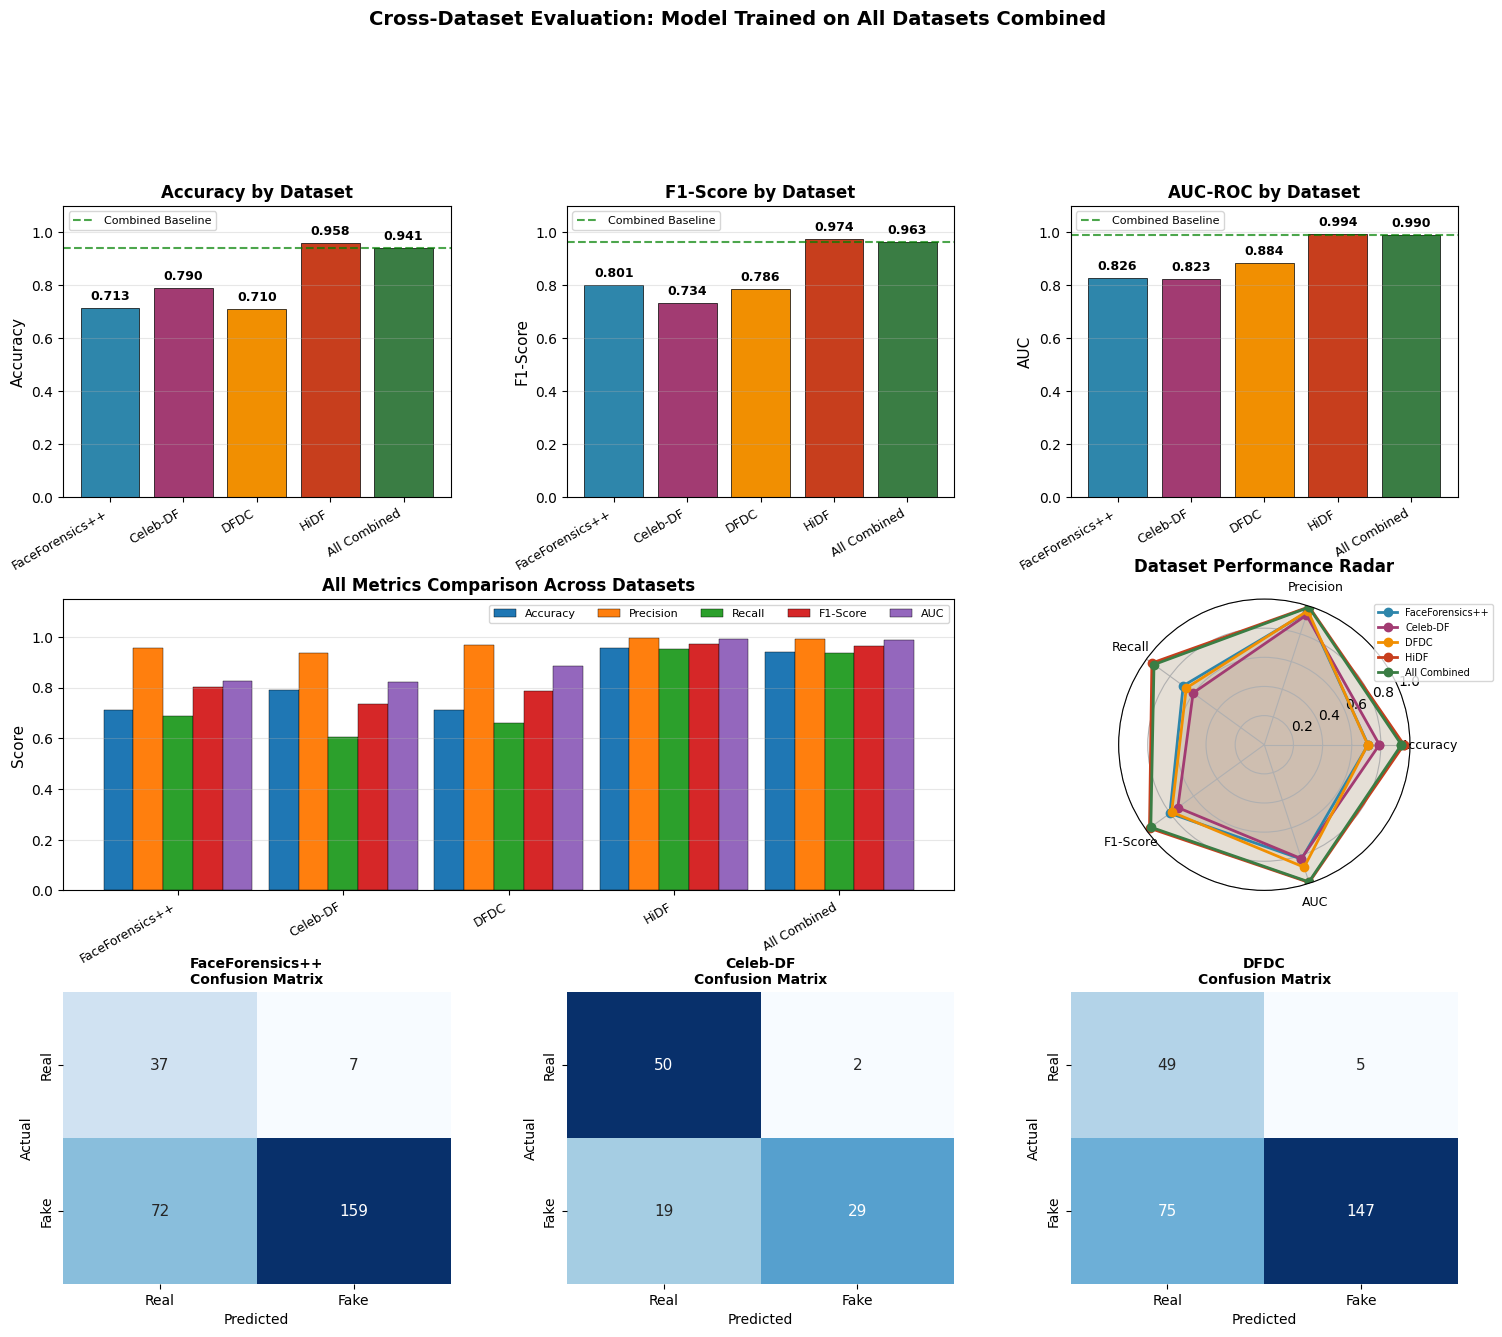


✓ Visualization saved to: results/cross_dataset_evaluation.png


In [20]:
# ============================================================================
# CROSS-DATASET EVALUATION VISUALIZATION
# ============================================================================

if cross_eval_results:
    fig = plt.figure(figsize=(18, 14))
    
    # Create grid for subplots
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
    
    # Color palette for datasets
    dataset_colors = {
        'FaceForensics++': '#2E86AB',
        'Celeb-DF': '#A23B72', 
        'DFDC': '#F18F01',
        'HiDF': '#C73E1D',
        'All Combined': '#3A7D44'
    }
    colors = [dataset_colors.get(name, '#666666') for name in cross_eval_df['Dataset']]
    
    # =========================================================================
    # Plot 1: Accuracy Comparison (Top Left)
    # =========================================================================
    ax1 = fig.add_subplot(gs[0, 0])
    bars = ax1.bar(cross_eval_df['Dataset'], cross_eval_df['Accuracy'], color=colors, edgecolor='black', linewidth=0.5)
    ax1.set_ylabel('Accuracy', fontsize=11)
    ax1.set_title('Accuracy by Dataset', fontsize=12, fontweight='bold')
    ax1.set_ylim(0, 1.1)
    ax1.axhline(y=cross_eval_df[cross_eval_df['Dataset'] == 'All Combined']['Accuracy'].values[0], 
                color='green', linestyle='--', alpha=0.7, label='Combined Baseline')
    for bar, acc in zip(bars, cross_eval_df['Accuracy']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=9)
    ax1.legend(fontsize=8)
    ax1.grid(axis='y', alpha=0.3)
    
    # =========================================================================
    # Plot 2: F1-Score Comparison (Top Middle)
    # =========================================================================
    ax2 = fig.add_subplot(gs[0, 1])
    bars = ax2.bar(cross_eval_df['Dataset'], cross_eval_df['F1-Score'], color=colors, edgecolor='black', linewidth=0.5)
    ax2.set_ylabel('F1-Score', fontsize=11)
    ax2.set_title('F1-Score by Dataset', fontsize=12, fontweight='bold')
    ax2.set_ylim(0, 1.1)
    ax2.axhline(y=cross_eval_df[cross_eval_df['Dataset'] == 'All Combined']['F1-Score'].values[0], 
                color='green', linestyle='--', alpha=0.7, label='Combined Baseline')
    for bar, f1 in zip(bars, cross_eval_df['F1-Score']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{f1:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=9)
    ax2.legend(fontsize=8)
    ax2.grid(axis='y', alpha=0.3)
    
    # =========================================================================
    # Plot 3: AUC Comparison (Top Right)
    # =========================================================================
    ax3 = fig.add_subplot(gs[0, 2])
    bars = ax3.bar(cross_eval_df['Dataset'], cross_eval_df['AUC'], color=colors, edgecolor='black', linewidth=0.5)
    ax3.set_ylabel('AUC', fontsize=11)
    ax3.set_title('AUC-ROC by Dataset', fontsize=12, fontweight='bold')
    ax3.set_ylim(0, 1.1)
    ax3.axhline(y=cross_eval_df[cross_eval_df['Dataset'] == 'All Combined']['AUC'].values[0], 
                color='green', linestyle='--', alpha=0.7, label='Combined Baseline')
    for bar, auc in zip(bars, cross_eval_df['AUC']):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{auc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=9)
    ax3.legend(fontsize=8)
    ax3.grid(axis='y', alpha=0.3)
    
    # =========================================================================
    # Plot 4: All Metrics Grouped Bar Chart (Middle Left)
    # =========================================================================
    ax4 = fig.add_subplot(gs[1, 0:2])
    x = np.arange(len(cross_eval_df))
    width = 0.18
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
    metric_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
        offset = (i - len(metrics)/2 + 0.5) * width
        bars = ax4.bar(x + offset, cross_eval_df[metric], width, label=metric, color=color, edgecolor='black', linewidth=0.3)
    
    ax4.set_ylabel('Score', fontsize=11)
    ax4.set_title('All Metrics Comparison Across Datasets', fontsize=12, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(cross_eval_df['Dataset'], rotation=30, ha='right', fontsize=9)
    ax4.legend(loc='upper right', fontsize=8, ncol=5)
    ax4.set_ylim(0, 1.15)
    ax4.grid(axis='y', alpha=0.3)
    
    # =========================================================================
    # Plot 5: Radar Chart for Dataset Comparison (Middle Right)
    # =========================================================================
    ax5 = fig.add_subplot(gs[1, 2], polar=True)
    
    categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Complete the loop
    
    for idx, row in cross_eval_df.iterrows():
        values = [row[cat] for cat in categories]
        values += values[:1]  # Complete the loop
        color = dataset_colors.get(row['Dataset'], '#666666')
        ax5.plot(angles, values, 'o-', linewidth=2, label=row['Dataset'], color=color)
        ax5.fill(angles, values, alpha=0.1, color=color)
    
    ax5.set_xticks(angles[:-1])
    ax5.set_xticklabels(categories, fontsize=9)
    ax5.set_ylim(0, 1)
    ax5.set_title('Dataset Performance Radar', fontsize=12, fontweight='bold', pad=20)
    ax5.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=7)
    
    # =========================================================================
    # Plot 6: Confusion Matrices (Bottom Row)
    # =========================================================================
    cm_datasets = ['FaceForensics++', 'Celeb-DF', 'DFDC', 'HiDF', 'All Combined']
    
    for i, dataset_name in enumerate(cm_datasets[:3]):  # First 3 in bottom row
        if dataset_name in cross_eval_results:
            ax_cm = fig.add_subplot(gs[2, i])
            cm = cross_eval_results[dataset_name]['confusion_matrix']
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                       xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
                       cbar=False, annot_kws={'fontsize': 11})
            ax_cm.set_xlabel('Predicted', fontsize=10)
            ax_cm.set_ylabel('Actual', fontsize=10)
            ax_cm.set_title(f'{dataset_name}\nConfusion Matrix', fontsize=10, fontweight='bold')
    
    plt.suptitle('Cross-Dataset Evaluation: Model Trained on All Datasets Combined', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.savefig(config.RESULTS_DIR / 'cross_dataset_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Visualization saved to: {config.RESULTS_DIR / 'cross_dataset_evaluation.png'}")
else:
    print("⚠ No cross-dataset evaluation results to visualize.")

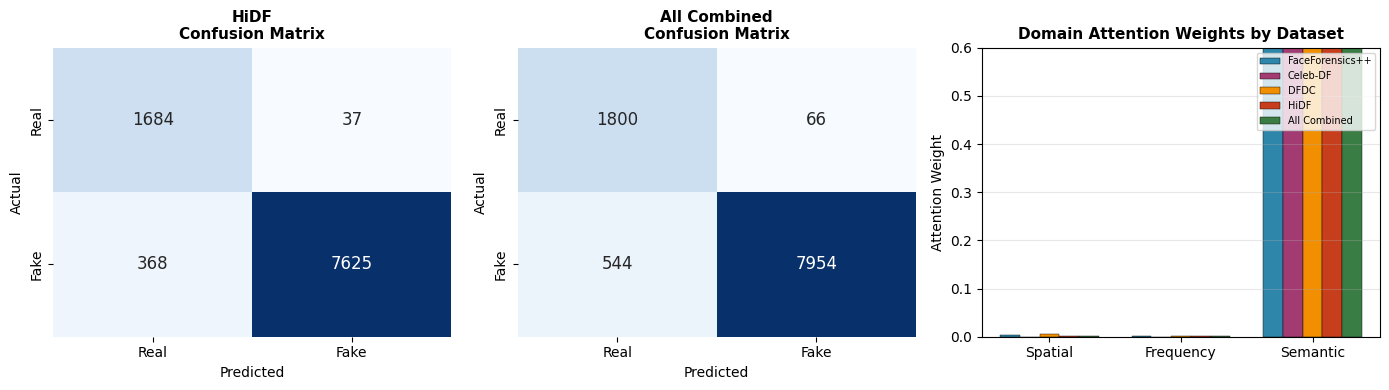

✓ Additional visualization saved to: results/cross_dataset_additional.png

DOMAIN ATTENTION WEIGHTS ANALYSIS

Domain Attention Weights per Dataset:
        Dataset       Spatial     Frequency        Semantic
FaceForensics++ 0.0032 (0.3%) 0.0018 (0.2%)  0.9950 (99.5%)
       Celeb-DF 0.0002 (0.0%) 0.0001 (0.0%) 0.9997 (100.0%)
           DFDC 0.0051 (0.5%) 0.0025 (0.3%)  0.9924 (99.2%)
           HiDF 0.0008 (0.1%) 0.0007 (0.1%)  0.9985 (99.9%)
   All Combined 0.0010 (0.1%) 0.0007 (0.1%)  0.9983 (99.8%)


In [21]:
# ============================================================================
# ADDITIONAL VISUALIZATIONS: Remaining Confusion Matrices & Domain Weights
# ============================================================================

if cross_eval_results:
    fig2, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    # =========================================================================
    # Plot remaining confusion matrices (HiDF and All Combined)
    # =========================================================================
    remaining_datasets = ['HiDF', 'All Combined']
    
    for i, dataset_name in enumerate(remaining_datasets):
        if dataset_name in cross_eval_results:
            cm = cross_eval_results[dataset_name]['confusion_matrix']
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                       xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
                       cbar=False, annot_kws={'fontsize': 12})
            axes[i].set_xlabel('Predicted', fontsize=10)
            axes[i].set_ylabel('Actual', fontsize=10)
            axes[i].set_title(f'{dataset_name}\nConfusion Matrix', fontsize=11, fontweight='bold')
    
    # =========================================================================
    # Plot Domain Attention Weights Comparison
    # =========================================================================
    ax_weights = axes[2]
    
    domain_labels = ['Spatial', 'Frequency', 'Semantic']
    x = np.arange(len(domain_labels))
    width = 0.15
    
    dataset_colors = {
        'FaceForensics++': '#2E86AB',
        'Celeb-DF': '#A23B72', 
        'DFDC': '#F18F01',
        'HiDF': '#C73E1D',
        'All Combined': '#3A7D44'
    }
    
    for i, (dataset_name, result) in enumerate(cross_eval_results.items()):
        if result['domain_weights'] is not None:
            weights = result['domain_weights']
            color = dataset_colors.get(dataset_name, '#666666')
            offset = (i - len(cross_eval_results)/2 + 0.5) * width
            ax_weights.bar(x + offset, weights, width, label=dataset_name, color=color, edgecolor='black', linewidth=0.3)
    
    ax_weights.set_ylabel('Attention Weight', fontsize=10)
    ax_weights.set_title('Domain Attention Weights by Dataset', fontsize=11, fontweight='bold')
    ax_weights.set_xticks(x)
    ax_weights.set_xticklabels(domain_labels, fontsize=10)
    ax_weights.legend(loc='upper right', fontsize=7)
    ax_weights.set_ylim(0, 0.6)
    ax_weights.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(config.RESULTS_DIR / 'cross_dataset_additional.png', dpi=150)
    plt.show()
    
    print(f"✓ Additional visualization saved to: {config.RESULTS_DIR / 'cross_dataset_additional.png'}")

# ============================================================================
# DOMAIN ATTENTION WEIGHTS SUMMARY TABLE
# ============================================================================

print(f"\n{'='*70}")
print("DOMAIN ATTENTION WEIGHTS ANALYSIS")
print(f"{'='*70}")

domain_labels = ['Spatial', 'Frequency', 'Semantic']

if cross_eval_results:
    weights_data = []
    for name, result in cross_eval_results.items():
        if result['domain_weights'] is not None:
            weights = result['domain_weights']
            weights_data.append({
                'Dataset': name,
                'Spatial': f"{weights[0]:.4f} ({weights[0]*100:.1f}%)",
                'Frequency': f"{weights[1]:.4f} ({weights[1]*100:.1f}%)",
                'Semantic': f"{weights[2]:.4f} ({weights[2]*100:.1f}%)"
            })
    
    if weights_data:
        weights_df = pd.DataFrame(weights_data)
        print("\nDomain Attention Weights per Dataset:")
        print(weights_df.to_string(index=False))

## Section 12: Performance Analysis & Insights

In [22]:
# ============================================================================
# PERFORMANCE ANALYSIS & INSIGHTS
# ============================================================================

print(f"\n{'='*70}")
print("CROSS-DATASET PERFORMANCE ANALYSIS")
print(f"{'='*70}")

if cross_eval_results and len(cross_eval_results) > 1:
    # Get 'All Combined' baseline
    combined_acc = cross_eval_results.get('All Combined', {}).get('accuracy', 0)
    combined_f1 = cross_eval_results.get('All Combined', {}).get('f1', 0)
    
    print("\n📊 GENERALIZATION ANALYSIS:")
    print(f"\nBaseline (All Combined): Accuracy={combined_acc:.4f}, F1={combined_f1:.4f}")
    print("\nPerformance relative to combined baseline:")
    print("-" * 50)
    
    for dataset_name, result in cross_eval_results.items():
        if dataset_name == 'All Combined':
            continue
        
        acc_diff = result['accuracy'] - combined_acc
        f1_diff = result['f1'] - combined_f1
        
        acc_symbol = "↑" if acc_diff >= 0 else "↓"
        f1_symbol = "↑" if f1_diff >= 0 else "↓"
        
        print(f"\n{dataset_name}:")
        print(f"  Accuracy: {result['accuracy']:.4f} ({acc_symbol} {abs(acc_diff)*100:.2f}%)")
        print(f"  F1-Score: {result['f1']:.4f} ({f1_symbol} {abs(f1_diff)*100:.2f}%)")
        
        # Classify performance
        if result['accuracy'] >= combined_acc:
            print(f"  Status: ✓ Generalizes WELL to this dataset")
        elif result['accuracy'] >= combined_acc - 0.1:
            print(f"  Status: ~ Moderate generalization drop")
        else:
            print(f"  Status: ⚠ Significant generalization gap")
    
    # Find best and worst performing datasets
    individual_results = {k: v for k, v in cross_eval_results.items() if k != 'All Combined'}
    
    if individual_results:
        best_dataset = max(individual_results.items(), key=lambda x: x[1]['f1'])
        worst_dataset = min(individual_results.items(), key=lambda x: x[1]['f1'])
        
        print(f"\n{'='*70}")
        print("KEY FINDINGS:")
        print(f"{'='*70}")
        print(f"\n✓ Best Generalization: {best_dataset[0]}")
        print(f"  F1-Score: {best_dataset[1]['f1']:.4f}, Accuracy: {best_dataset[1]['accuracy']:.4f}")
        
        print(f"\n⚠ Most Challenging: {worst_dataset[0]}")
        print(f"  F1-Score: {worst_dataset[1]['f1']:.4f}, Accuracy: {worst_dataset[1]['accuracy']:.4f}")
        
        # Calculate average performance
        avg_acc = np.mean([r['accuracy'] for r in individual_results.values()])
        avg_f1 = np.mean([r['f1'] for r in individual_results.values()])
        std_acc = np.std([r['accuracy'] for r in individual_results.values()])
        std_f1 = np.std([r['f1'] for r in individual_results.values()])
        
        print(f"\n📈 OVERALL STATISTICS:")
        print(f"  Average Accuracy: {avg_acc:.4f} (±{std_acc:.4f})")
        print(f"  Average F1-Score: {avg_f1:.4f} (±{std_f1:.4f})")
        
        # Consistency check
        if std_f1 < 0.1:
            print(f"\n  Consistency: ✓ Model performs consistently across datasets (low variance)")
        elif std_f1 < 0.2:
            print(f"\n  Consistency: ~ Moderate variance in cross-dataset performance")
        else:
            print(f"\n  Consistency: ⚠ High variance - model may be biased towards certain datasets")
else:
    print("⚠ Insufficient results for cross-dataset analysis")


CROSS-DATASET PERFORMANCE ANALYSIS

📊 GENERALIZATION ANALYSIS:

Baseline (All Combined): Accuracy=0.9411, F1=0.9631

Performance relative to combined baseline:
--------------------------------------------------

FaceForensics++:
  Accuracy: 0.7127 (↓ 22.84%)
  F1-Score: 0.8010 (↓ 16.21%)
  Status: ⚠ Significant generalization gap

Celeb-DF:
  Accuracy: 0.7900 (↓ 15.11%)
  F1-Score: 0.7342 (↓ 22.89%)
  Status: ⚠ Significant generalization gap

DFDC:
  Accuracy: 0.7101 (↓ 23.10%)
  F1-Score: 0.7861 (↓ 17.70%)
  Status: ⚠ Significant generalization gap

HiDF:
  Accuracy: 0.9583 (↑ 1.72%)
  F1-Score: 0.9741 (↑ 1.11%)
  Status: ✓ Generalizes WELL to this dataset

KEY FINDINGS:

✓ Best Generalization: HiDF
  F1-Score: 0.9741, Accuracy: 0.9583

⚠ Most Challenging: Celeb-DF
  F1-Score: 0.7342, Accuracy: 0.7900

📈 OVERALL STATISTICS:
  Average Accuracy: 0.7928 (±0.1008)
  Average F1-Score: 0.8239 (±0.0902)

  Consistency: ✓ Model performs consistently across datasets (low variance)


## Section 13: Final Summary

In [23]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================

print(f"\n{'#'*70}")
print("# INTEGRATED TRAINING COMPLETE - FINAL SUMMARY")
print(f"{'#'*70}")

print(f"\n📊 Configuration:")
print(f"  - Model: Complete Attention Model (3-Domain)")
print(f"  - Data Percentages:")
print(f"      FaceForensics++: {config.FFPP_PERCENTAGE * 100:.1f}%")
print(f"      Celeb-DF: {config.CELEBDF_PERCENTAGE * 100:.1f}%")
print(f"      DFDC: {config.DFDC_PERCENTAGE * 100:.1f}%")
print(f"      HiDF: {config.HIDF_PERCENTAGE * 100:.1f}%")
print(f"  - Feature Dimensions: Spatial({config.SPATIAL_DIM}), Freq({config.FREQ_DIM}), Semantic({config.SEMANTIC_DIM})")

print(f"\n📈 Training Results:")
if result_all and 'metrics' in result_all:
    metrics = result_all['metrics']
    print(f"  - Training Accuracy: {metrics.get('accuracy', 0):.4f}")
    print(f"  - Training F1-Score: {metrics.get('f1', 0):.4f}")
    print(f"  - Training AUC: {metrics.get('auc', 0):.4f}")

print(f"\n🔬 Cross-Dataset Evaluation:")
if cross_eval_results:
    for name, result in cross_eval_results.items():
        print(f"  - {name}: Acc={result['accuracy']:.4f}, F1={result['f1']:.4f}")

print(f"\n📁 Saved Files:")
print(f"  - Metadata: {config.INTEGRATED_METADATA_PATH}")
print(f"  - Cross-Dataset Results: {config.RESULTS_DIR / 'cross_dataset_evaluation.csv'}")
print(f"  - Visualizations: {config.RESULTS_DIR / 'cross_dataset_evaluation.png'}")
print(f"  - Model Checkpoint: {config.CHECKPOINTS_DIR / 'complete_attention_all_datasets_best.pth'}")

# Save final results as JSON
final_results = {
    'config': {
        'ffpp_percentage': config.FFPP_PERCENTAGE,
        'celebdf_percentage': config.CELEBDF_PERCENTAGE,
        'dfdc_percentage': config.DFDC_PERCENTAGE,
        'hidf_percentage': config.HIDF_PERCENTAGE,
        'model_type': 'CompleteAttentionModel',
        'epochs': config.EPOCHS,
        'batch_size': config.BATCH_SIZE
    },
    'training_metrics': result_all['metrics'] if result_all else {},
    'cross_dataset_evaluation': {
        name: {k: v for k, v in result.items() if k not in ['confusion_matrix', 'predictions', 'labels', 'probabilities', 'domain_weights']}
        for name, result in cross_eval_results.items()
    } if cross_eval_results else {}
}

with open(config.RESULTS_DIR / 'final_results.json', 'w') as f:
    json.dump(final_results, f, indent=2, default=str)

print(f"  - Final Results JSON: {config.RESULTS_DIR / 'final_results.json'}")

print(f"\n{'#'*70}")
print("# TRAINING PIPELINE COMPLETE")
print(f"{'#'*70}")


######################################################################
# INTEGRATED TRAINING COMPLETE - FINAL SUMMARY
######################################################################

📊 Configuration:
  - Model: Complete Attention Model (3-Domain)
  - Data Percentages:
      FaceForensics++: 1.0%
      Celeb-DF: 5.0%
      DFDC: 30.0%
      HiDF: 10.0%
  - Feature Dimensions: Spatial(2048), Freq(4), Semantic(768)

📈 Training Results:
  - Training Accuracy: 0.9411
  - Training F1-Score: 0.9631
  - Training AUC: 0.9900

🔬 Cross-Dataset Evaluation:
  - FaceForensics++: Acc=0.7127, F1=0.8010
  - Celeb-DF: Acc=0.7900, F1=0.7342
  - DFDC: Acc=0.7101, F1=0.7861
  - HiDF: Acc=0.9583, F1=0.9741
  - All Combined: Acc=0.9411, F1=0.9631

📁 Saved Files:
  - Metadata: integrated_nocuda.csv
  - Cross-Dataset Results: results/cross_dataset_evaluation.csv
  - Visualizations: results/cross_dataset_evaluation.png
  - Model Checkpoint: checkpoints/complete_attention_all_datasets_best.pth
  - Final 